In [1]:
%load_ext autoreload
%autoreload 2

### Packages et import

In [2]:
import os, requests, warnings
import pandas as pd
from hydrosense.params import *

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Controle du repertoire de travail :", os.getcwd())


Controle du repertoire de travail : /home/charourou/projects/Projet_Hydrosense


In [3]:
from hydrosense.database.meteo import CatalogueMeteo
from hydrosense.preprocess.meteo_fusion import SynthPrecipitation

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.6) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [4]:
CLIM_DATASET_ID='6569b51ae64326786e4e8e1a'
API_URL = f"https://www.data.gouv.fr/api/1/datasets/{CLIM_DATASET_ID}/"

In [5]:
reponse = requests.get(API_URL)
reponse.raise_for_status()

In [6]:
reponse.json()

{'access_audiences': [],
 'access_type': 'open',
 'access_type_reason': None,
 'access_type_reason_category': None,
 'acronym': None,
 'archived': None,
 'authorization_request_url': None,
 'badges': [{'kind': 'hvd'}],
 'contact_points': [],
 'created_at': '2023-12-01T10:27:38.839000+00:00',
 'deleted': None,
 'description': "### Présentation\n\nDonnées climatologiques de toutes les stations de métropole et d'outre-mer depuis leur ouverture, pour tous les paramètres disponibles. Ces données ont subi un contrôle climatologique.\n\n### Informations techniques\n\n- Les données quotidiennes sont proposées en téléchargement, par département, et par lots de période au format csv compressé\n- L'ensemble des paramètres est fourni pour l'ensemble des stations météorologiques\n- Les heures sont exprimées en UTC pour la métropole et en FU pour l'outre-mer\n- La mise à jour des fichiers est annuelle pour les historiques avant 1950, mensuelles pour les fichiers de 1950 jusqu'à l'année -2 et quotidi

In [17]:
list_url = [
    {'titre': res.get('title'), 'url': res.get('url')}
            for res in reponse.json().get('resources', [])
            if res.get('title', '').startswith('Q') and "RR-T-Vent" in res.get('title', '')
        ]

print(list_url[:10])
'avant' in list_url[1]['titre']

[{'titre': 'Q_descriptif_champs_RR-T-Vent.csv', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_descriptif_champs_RR-T-Vent.csv'}, {'titre': 'QUOT_departement_01_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_01_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_01_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_01_previous-1950-2024_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_01_periode_2025-2026_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_01_latest-2025-2026_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_02_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_02_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_02_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/met

True

### 0.1 Import des Précipitations sur le piezo

In [8]:
from hydrosense.database.bigquery import load_piezo_bq, info_piezo, save_dataframe_to_bq
from hydrosense.preprocess.cleaning import clean_piezo

bss = TARGETS_BSS[1]
info = info_piezo(bss)
departement = str(info['code_departement'].iloc[0])
print(info, '\nDepartement du piezo : ',departement)

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  altitude_station      bss_id code_departement     codes_bdlisa  \
0             14.0  BSS000ZPHJ               35  174AA01,938AC01   

  codes_masse_eau_edl         date_debut_mesure           date_fin_mesure  \
0               GG115 2005-12-22 00:00:00+00:00 2026-05-27 00:00:00+00:00   

   nb_mesures_piezo        nom_commune  profondeur_investigation  ...  \
0              7421  Bourg-des-Comptes                      10.0  ...   

   niveau_median  niveau_std  total_jours_manquants  taux_completude  \
0          10.67    0.684632                     41            99.45   

   p95_global  p85_global  p50_global  p20_global  p10_global  p5_global  
0         NaN         NaN         NaN         NaN         NaN        NaN  

[1 rows x 25 columns] 
Departement du piezo :  35


In [37]:
import random

random.seed(42)
bss = random.choice(TARGETS_BSS)


info = info_piezo(bss)
departement = str(info['code_departement'].iloc[0])
print('Departement du piezo : ',departement)

df_piezo = clean_piezo(load_piezo_bq(bss))
synthetiseur = SynthPrecipitation(df_piezo, bss)
resultat = synthetiseur.search(departement, n_neighbors=3, dep_voisins= False)
df_final = synthetiseur.merge(resultat)


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Departement du piezo :  79
BSS001PGUQ : 13293 lignes chargées
Trou de 54 jours détecté ! 8072 lignes supprimées.
DataFrame final : 2012-02-13 00:00:00 → 2026-05-30 00:00:00 | 5221 jours


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


🌍 Recherche STRICTE limitée au département : 79...
🌍 Recherche des stations météo pour le département 79...
[{'titre': 'QUOT_departement_79_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_79_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_79_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_79_previous-1950-2024_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_79_periode_2025-2026_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_79_latest-2025-2026_RR-T-Vent.csv.gz'}]
🔍 Analyse du fichier de référence : QUOT_departement_79_periode_2025-2026_RR-T-Vent
🎯 17 stations actives identifiées pour le 79.
📖 Récupération de l'historique : QUOT_departement_79_periode_1950-2024_RR-T-Vent.csv.gz
⚙️ Nettoyage et assemblage final pour 17 stations...
✅ Extraction départementale terminée !
🎯 Station météo retenue : 791910

In [38]:
cols = ['date_mesure','niveau_nappe_eau','RR_synth','TM_synth','FFM_synth']
df_final = df_final[cols]

df_pu = synthetiseur.calc_PU(df_final)
df_pu


💧 Calcul de la Pluie Utile (Penman-Monteith)...


,date_mesure,niveau_nappe_eau,RR_synth,TM_synth,FFM_synth,PU_synth
0,2012-02-13,33.30,1.02,1.72,1.9,-0.002
1,2012-02-14,33.30,0.22,3.66,3.4,-1.234
2,2012-02-15,31.87,0.00,4.87,2.6,-1.381
3,2012-02-16,31.88,0.00,6.39,2.5,-1.466
4,2012-02-17,31.88,0.00,7.13,1.3,-1.149
...,...,...,...,...,...,...
5216,2026-05-26,31.30,0.00,27.68,2.7,-5.579
5217,2026-05-27,31.27,0.00,27.53,2.2,-5.315
5218,2026-05-28,31.23,0.00,27.96,1.9,-5.217
5219,2026-05-29,31.20,0.00,27.32,2.1,-5.256


### Chargement Catalogue intermediate 

In [39]:
from google.cloud import bigquery

TABLE = "cat_piezo_interm"
MIN_COMPLETUDE = 0.8

client = bigquery.Client(project=GCP_PROJECT_ID)

query = f"""
            SELECT *
            FROM `{GCP_PROJECT_ID}.{BQ_DATASET_ID}.{TABLE}`
            WHERE taux_completude > {MIN_COMPLETUDE}
        """
try:
    query_job = client.query(query)
    result = query_job.result()
    cat_clean = result.to_dataframe()
except:
    print("Not uploaded from Big Query")

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### Test etape 4 et etape 5


In [ ]:
from hydrosense.preprocess.features import enrichir_contexte_regional

# ÉTAPE 4 & 5 : Contexte Régional (Voisins) + Jointure
df_enrichi = enrichir_contexte_regional(
        df_cible=df_pu,
        bss_cible=bss,
        df_catalogue=cat_clean,
        n_voisins=10
    )



🌍 ÉTAPE 4 : Recherche du contexte régional pour BSS001PGUQ...
   ✔️ 10 voisins trouvés. Calcul de l'ACP...
🔄 Récupération et alignement des voisins...
BSS001PHQG : 13682 lignes chargées
Trou de 292 jours détecté ! 5081 lignes supprimées.
DataFrame final : 2002-06-17 00:00:00 → 2026-05-30 00:00:00 | 8749 jours
BSS001PHKF : 12101 lignes chargées
DataFrame final : 1993-03-09 00:00:00 → 2026-05-30 00:00:00 | 12136 jours
BSS001PKJB : 11771 lignes chargées
Trou de 73 jours détecté ! 3211 lignes supprimées.
DataFrame final : 2002-06-12 00:00:00 → 2026-05-30 00:00:00 | 8754 jours
BSS001PHJU : 13062 lignes chargées
Trou de 185 jours détecté ! 2320 lignes supprimées.
DataFrame final : 1997-01-01 00:00:00 → 2026-05-30 00:00:00 | 10742 jours
BSS001PHJT : 12918 lignes chargées
Trou de 185 jours détecté ! 2221 lignes supprimées.
DataFrame final : 1997-01-01 00:00:00 → 2026-05-30 00:00:00 | 10742 jours
BSS001PJNW : 18150 lignes chargées
Trou de 429 jours détecté ! 3683 lignes supprimées.
DataFrame f

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,date_mesure,niveau_nappe_eau,RR_synth,TM_synth,FFM_synth,PU_synth,PC1,PC2,PC3
0,2012-02-13,33.30,1.02,1.72,1.9,-0.002,1.409674,1.155364,0.411712
1,2012-02-14,33.30,0.22,3.66,3.4,-1.234,1.361519,1.163769,0.424488
2,2012-02-15,31.87,0.00,4.87,2.6,-1.381,1.317915,1.159248,0.440119
3,2012-02-16,31.88,0.00,6.39,2.5,-1.466,1.281082,1.147942,0.456215
4,2012-02-17,31.88,0.00,7.13,1.3,-1.149,1.248612,1.132456,0.471381
...,...,...,...,...,...,...,...,...,...
5216,2026-05-26,31.30,0.00,27.68,2.7,-5.579,0.188085,0.977877,0.227155
5217,2026-05-27,31.27,0.00,27.53,2.2,-5.315,0.135016,0.980759,0.222889
5218,2026-05-28,31.23,0.00,27.96,1.9,-5.217,0.079506,0.985918,0.225298
5219,2026-05-29,31.20,0.00,27.32,2.1,-5.256,0.018394,0.989303,0.222224


In [50]:
print(df_enrichi.columns)
df_enrichi.describe()

DOSSIER_SORTIE = 'data/processed_pem/'
fichier_sortie = DOSSIER_SORTIE + f"pem_{bss}.parquet"
df_enrichi.to_parquet(fichier_sortie, index=False, compression='snappy')

Index(['date_mesure', 'niveau_nappe_eau', 'RR_synth', 'TM_synth', 'FFM_synth',
       'PU_synth', 'PC1', 'PC2', 'PC3'],
      dtype='object')


In [51]:
!ls data/processed_pem/


pem_BSS001PGUQ.parquet


### Productions de tables Plean 

In [ ]:
# Production des plean
for i, bss in enumerate(TARGETS_BSS):
    info = info_piezo(bss)

### OLD : Productions de tables PEM. 

In [ ]:

# Production des ple
for bss in TARGETS_BSS[:]:
    info = info_piezo(bss)
    departement = str(info['code_departement'].iloc[0])
    print('Departement du piezo : ',departement)

    df_piezo = clean_piezo(load_piezo_bq(bss))
    synthetiseur = SynthPrecipitation(df_piezo, bss)
    resultat = synthetiseur.search(departement)
    df_final = synthetiseur.merge(resultat)

    if False:
        print(df_final.sample(15), df_final.info())

    save_dataframe_to_bq(df_final, bss,  write_mode="WRITE_TRUNCATE")


#### 0.4 Nouvelle fonction pour uploader les PEMs vers bigquery 

`save_dataframe_to_bq(df_final, bss,  write_mode="WRITE_TRUNCATE")`


In [ ]:
# from google.cloud import bigquery
# # Send the fusion df to big query as a pem name: "pem_" + bss
# TABLE = "pem_" + bss
# table = f"{GCP_PROJECT_ID}.{BQ_DATASET_ID}.{TABLE}"

# client = bigquery.Client()

# write_mode = "WRITE_TRUNCATE" # or "WRITE_APPEND"
# job_config = bigquery.LoadJobConfig(write_disposition=write_mode)

# job = client.load_table_from_dataframe(df_final, table, job_config=job_config)
# result = job.result()


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


### 1. Le "Sanity Check" (L'état des lieux)

Regarder la complétude et la distribution des données synthétiques.

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


print("Valeurs manquantes par colonne :")
print(df_final.isna().sum())

print("\nStatistiques descriptives :")
print(df_final[['RR_synth', 'TM_synth', 'niveau_nappe_eau']].describe())


Valeurs manquantes par colonne :
date_mesure             0
niveau_nappe_eau        0
RR_40286001           121
TM_40286001         10767
FFM_40286001        12261
RR_40192001             0
TM_40192001             3
FFM_40192001            2
RR_40031001            31
TM_40031001         10262
FFM_40031001        12261
RR_synth                0
TM_synth                3
FFM_synth               2
dtype: int64

Statistiques descriptives :
           RR_synth     TM_synth  niveau_nappe_eau
count  12261.000000  12258.00000      12261.000000
mean       2.791557     13.53265         26.830740
std        5.688511      6.44205          0.623677
min        0.000000     -6.80000         25.410000
25%        0.000000      8.83750         26.350000
50%        0.140000     13.50000         26.800000
75%        2.860000     18.60000         27.230000
max       63.780000     30.11000         29.300000


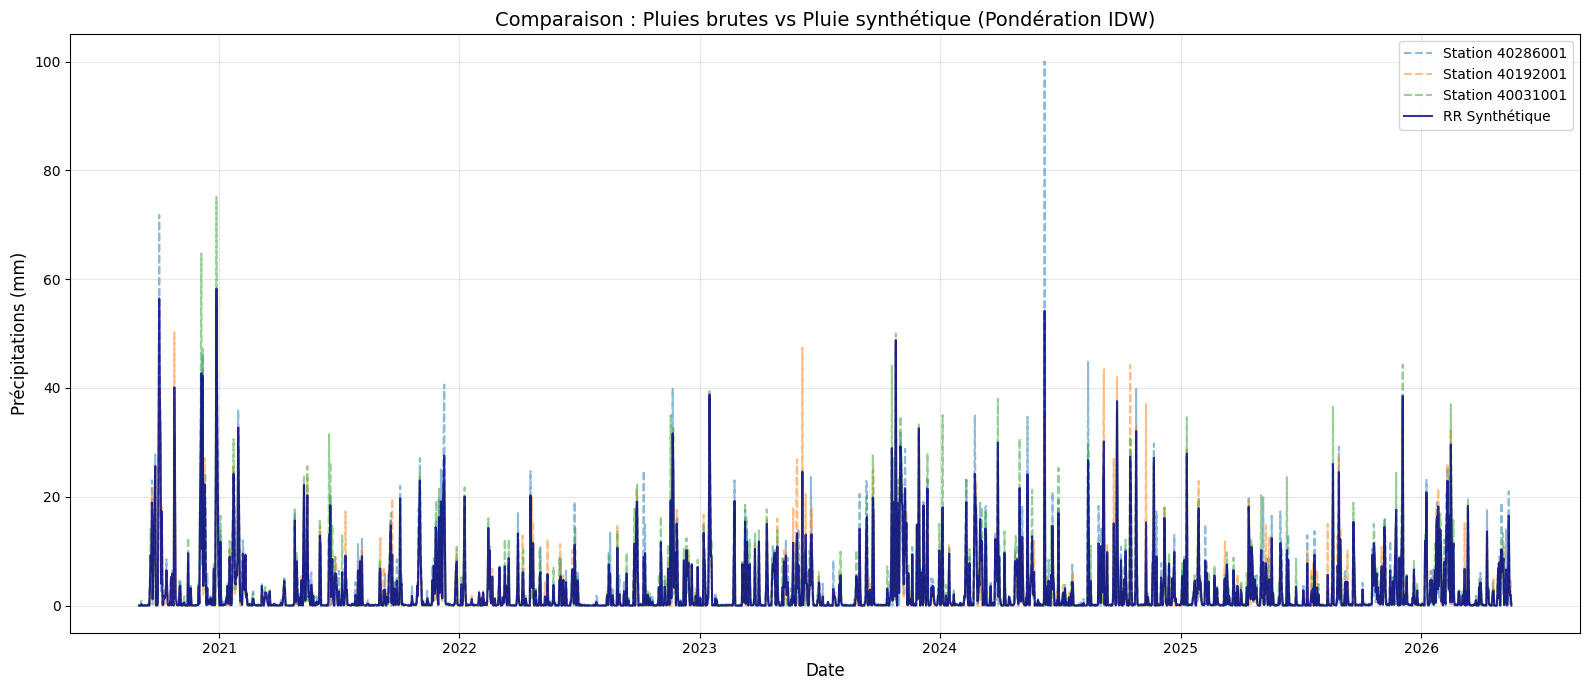

In [49]:
start_date = '2020-09-01'
end_date = '2026-09-01'
mask = (df_final['date_mesure'] >= start_date) & (df_final['date_mesure'] <= end_date)
df_zoom = df_final.loc[mask]

# 2. Identification des colonnes
cols_rr = [c for c in df_final.columns if ('RR_' in c and c[-1].isnumeric())]
col_synth = 'RR_synth'


plt.figure(figsize=(16, 7))
for col in cols_rr:
    plt.plot(df_zoom['date_mesure'], df_zoom[col], alpha=0.5, linestyle='--', label=f"Station {col.split('_')[1]}")

# Tracé de la synthèse avec une ligne plus épaisse et colorée
plt.plot(df_zoom['date_mesure'], df_zoom[col_synth], alpha = 0.8, color='darkblue', linewidth=1.5, label='RR Synthétique')

plt.title(f"Comparaison : Pluies brutes vs Pluie synthétique (Pondération IDW)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Précipitations (mm)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()


## 2. L'Hydrogramme Pluie-Niveau

En hydrogéologie, l'hydrogramme avec les précipitations inversées en haut (qui "tombent" vers le bas) et le niveau de la nappe en bas. C'est ce qui permet de voir "à l'œil nu" si la nappe réagit vite aux épisodes pluvieux.

Créer un graphique à double axe

In [1]:
df_zoom = df_final[(df_final['date_mesure'] >= '2015-01-01') & (df_final['date_mesure'] <= '2018-01-01')]
fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Niveau de la nappe (m)', color=color)
ax1.plot(df_zoom['date_mesure'], df_zoom['niveau_nappe_eau'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# La pluie synthétique (en gris/bleu clair, inversé)
ax2 = ax1.twinx()
color = 'tab:gray'
ax2.set_ylabel('Précipitations (mm)', color=color)
ax2.bar(df_zoom['date_mesure'], df_zoom['RR_synth'], color=color, alpha=0.5, width=1)
ax2.tick_params(axis='y', labelcolor=color)

# On inverse l'axe des ordonnées pour la pluie (effet "chute d'eau")
ax2.set_ylim(ax2.get_ylim()[::-1])
ax2.set_ylim(df_zoom['RR_synth'].max() * 2, 0)

plt.title("Hydrogramme : Réaction de la nappe face aux précipitations")
fig.tight_layout()
plt.show()

NameError: name 'df_final' is not defined

## 3. La Recherche du "Temps de Réponse" (Cross-Correlation)

L'eau met du temps à s'infiltrer à travers le sol pour atteindre l'aquifère. S'il pleut aujourd'hui, le niveau de la nappe ne montera peut-être que dans 10, 20 ou 40 jours.

Calculer la corrélation croisée (Lags) pour trouver le délai de recharge.

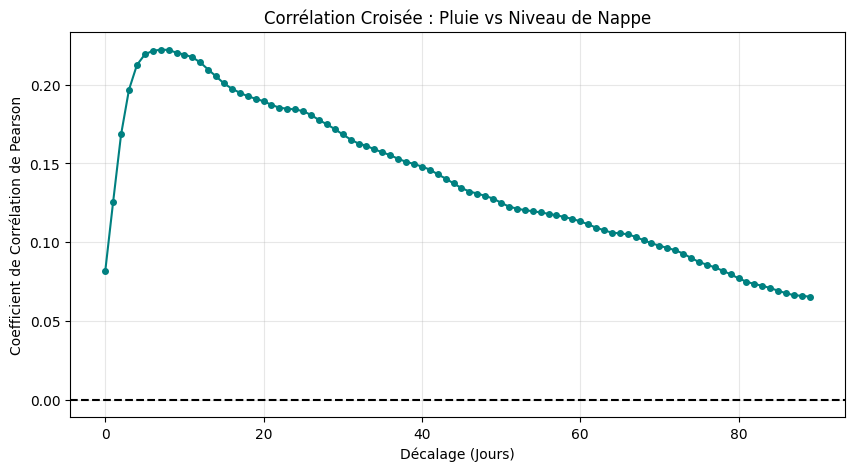

Le temps de réponse optimal estimé de la nappe est de 7 jours.


In [53]:
# On s'assure de ne pas avoir de NaN pour le calcul de corrélation
df_corr = df_final[['RR_synth', 'niveau_nappe_eau']].dropna()

lags = range(0, 90) # On teste des décalages de 0 à 90 jours
corr_values = []

for lag in lags:
    # On décale la pluie vers le futur (ou le niveau vers le passé)
    # Pour voir si la pluie du jour J est corrélée au niveau du jour J+lag
    corr = df_corr['RR_synth'].corr(df_corr['niveau_nappe_eau'].shift(-lag))
    corr_values.append(corr)

plt.figure(figsize=(10, 5))
plt.plot(lags, corr_values, marker='o', color='teal', markersize=4)
plt.axhline(0, color='black', linestyle='--')
plt.title("Corrélation Croisée : Pluie vs Niveau de Nappe")
plt.xlabel("Décalage (Jours)")
plt.ylabel("Coefficient de Corrélation de Pearson")
plt.grid(True, alpha=0.3)
plt.show()

best_lag = lags[np.argmax(np.abs(corr_values))]
print(f"Le temps de réponse optimal estimé de la nappe est de {best_lag} jours.")

## 4. Une petite Heatmap

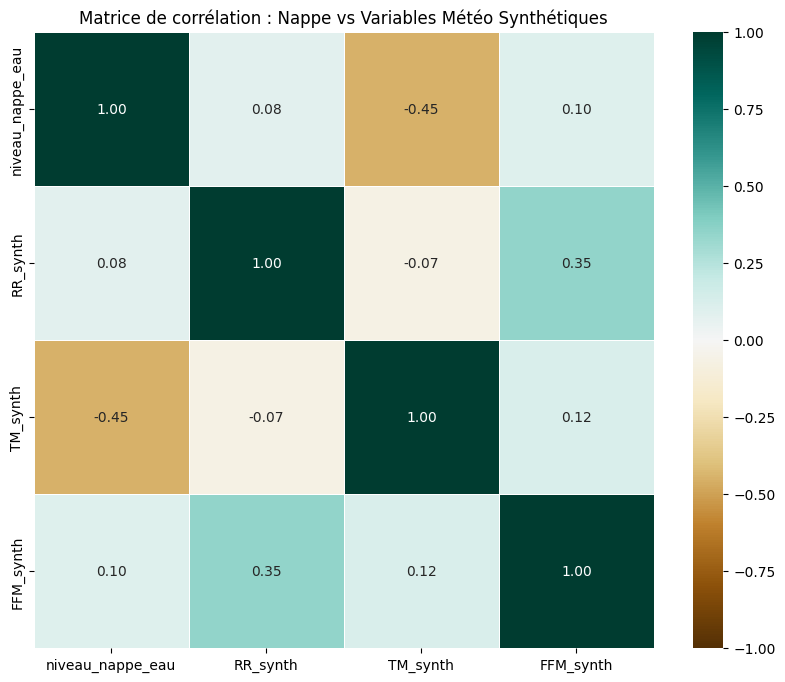

In [55]:
# 1. Calcul de la matrice de corrélation
# On sélectionne uniquement les colonnes numériques pertinentes
cols_to_corr = ['niveau_nappe_eau', 'RR_synth', 'TM_synth','FFM_synth']
corr_mat = df_final[cols_to_corr].corr()

# 2. Configuration de la figure
plt.figure(figsize=(10, 8))

# 3. Création de la Heatmap
sns.heatmap(
    corr_mat,
    vmin=-1,
    vmax=1,
    cmap='BrBG',
    linewidths=.5,
    annot=True,
    annot_kws={"size": 10},
    fmt=".2f" # Pour limiter à 2 décimales et garder la lisibilité
)

plt.title("Matrice de corrélation : Nappe vs Variables Météo Synthétiques")
plt.show()